# Overview
- Count
- Temporal distribution
- Geographical distribution
- Wind distribution

# DATA

In [2]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import put_fig_letter, update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby, compute_variance, put_fig_letter

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

/Users/mdemol/code/pynsitu/pynsitu/__init__.py:45: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  hour = Timedelta("1H")


____
# Data

In [3]:
dt=12
alti_product_key='swot2km'
drifter_preprocess = ''
drifter_preprocess_param=''
from diagnosis import define_coloc_source
colocs_sources = define_coloc_source('12h', drifter_preprocess, drifter_preprocess_param)



In [4]:
DT = 3
distance_to_coast_max = 20e3
alti_product_key='swot2km'

base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot2km',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


DS = dataset_coloc_combs([base_dic, update_dict(base_dic, {'alti_product_key':'swot250m'})], nearest =False)
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<DT).dropna('row_number')

df250 = DS.isel(id_comb=1).to_dataframe().dropna()
df2 = DS.isel(id_comb=0).to_dataframe().dropna()
len(df250), len(df2)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mdemol/DATA_MED_COLOC_v2.0.1/coloc_files/alti/alticoloc_swot2km_general_12h_spectral_decomp_all_med_variational_10min_v1.csv'

In [7]:
df2.drifter_type.unique()

array(['SVP', 'CARTHE', 'MELODI', 'SPOTTER', 'SVPOGS', 'SVPSIO', 'SVPBGC',
       'CODE', 'SVP-B', 'HEREON'], dtype=object)

In [8]:
df2.depth.unique()

array([ 15.,   0., 100.,  50.])

In [9]:
df250.groupby('drifter_type').longitude.count(), df2.groupby('drifter_type').longitude.count()

(drifter_type
 CARTHE     28029
 CODE         986
 HEREON      9376
 MELODI      2393
 SPOTTER      286
 SVP        22326
 SVP-B       4721
 SVPBGC       144
 SVPOGS      1753
 SVPSIO      7150
 Name: longitude, dtype: int64,
 drifter_type
 CARTHE     28029
 CODE         986
 HEREON      9376
 MELODI      2393
 SPOTTER      286
 SVP        22326
 SVP-B       4721
 SVPBGC       144
 SVPOGS      1753
 SVPSIO      7150
 Name: longitude, dtype: int64)

In [10]:
df250.groupby('depth').longitude.count(), df2.groupby('depth').longitude.count()

(depth
 0.0      41070
 15.0     32346
 50.0      1605
 100.0     2143
 Name: longitude, dtype: int64,
 depth
 0.0      41070
 15.0     32346
 50.0      1605
 100.0     2143
 Name: longitude, dtype: int64)

In [11]:
df250n = select_nearest_swot_coloc(df250)
df2n = select_nearest_swot_coloc(df2)
len(df250n), len(df2n)

(2317, 2317)

In [12]:
df250n.groupby('drifter_type').longitude.count(), df2n.groupby('drifter_type').longitude.count()

(drifter_type
 CARTHE     851
 CODE        35
 HEREON     279
 MELODI      83
 SPOTTER     11
 SVP        657
 SVP-B      139
 SVPBGC       4
 SVPOGS      52
 SVPSIO     206
 Name: longitude, dtype: int64,
 drifter_type
 CARTHE     851
 CODE        35
 HEREON     279
 MELODI      83
 SPOTTER     11
 SVP        657
 SVP-B      139
 SVPBGC       4
 SVPOGS      52
 SVPSIO     206
 Name: longitude, dtype: int64)

In [13]:
df250n.groupby('depth').longitude.count(), df2n.groupby('depth').longitude.count()

(depth
 0.0      1259
 15.0      949
 50.0       48
 100.0      61
 Name: longitude, dtype: int64,
 depth
 0.0      1259
 15.0      949
 50.0       48
 100.0      61
 Name: longitude, dtype: int64)

In [14]:
df250n.groupby('drifter_type').longitude.count(), df2n.groupby('drifter_type').longitude.count()

(drifter_type
 CARTHE     851
 CODE        35
 HEREON     279
 MELODI      83
 SPOTTER     11
 SVP        657
 SVP-B      139
 SVPBGC       4
 SVPOGS      52
 SVPSIO     206
 Name: longitude, dtype: int64,
 drifter_type
 CARTHE     851
 CODE        35
 HEREON     279
 MELODI      83
 SPOTTER     11
 SVP        657
 SVP-B      139
 SVPBGC       4
 SVPOGS      52
 SVPSIO     206
 Name: longitude, dtype: int64)

__________
# Add other info

In [24]:
dfs = pd.read_csv(os.path.join(zarr_dir, 'coloc_files', 'alti',f'alticoloc_{alti_product_key}_general_'+colocs_sources+'.csv')).set_index('row_number')
dfrr = pd.concat([dfs[['swh_model']], df2], axis=1).dropna()

dfw = pd.read_csv(os.path.join(zarr_dir,'coloc_files','wind','era5_rioagesc_'+colocs_sources.replace('.nc', '')+'.csv'))
dfrr = pd.concat([dfw[['u10', 'v10']], dfrr], axis=1).dropna()
dfrr['U10'] = np.sqrt(dfrr.u10**2 + dfrr.v10**2)

In [25]:
dl = 0.5/10
dfrr["latbin"] = (dfrr.latitude // dl) * dl
dfrr["lonbin"] = (dfrr.longitude // dl) * dl
dd = dfrr.groupby(["latbin", "lonbin"]).longitude.count().to_xarray()
dd.name = f'Number of colocation per geographical bins of {dl}°'
dd['lonbin'] = dd['lonbin']+dl/2
dd['latbin'] = dd['latbin']+dl/2

_______
# Overview Distribution

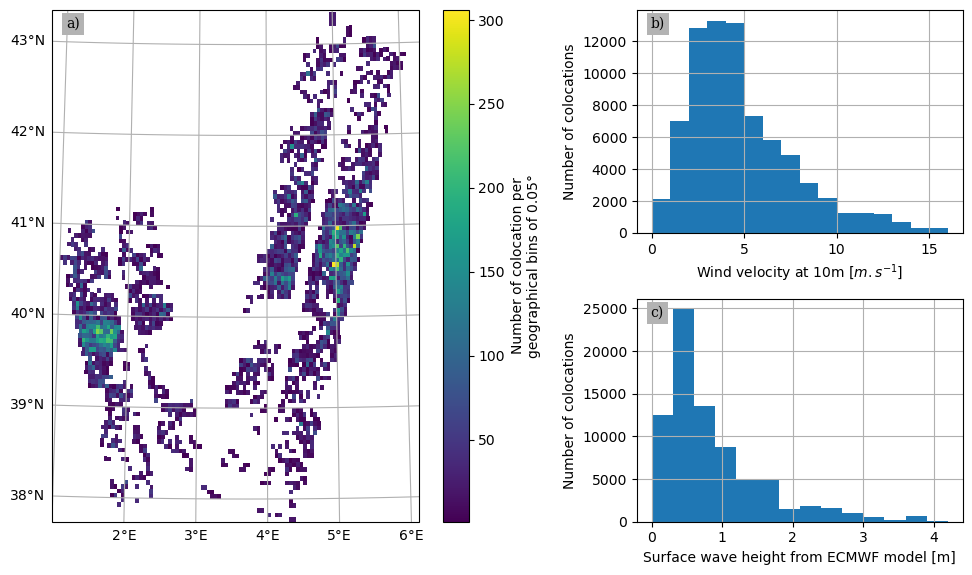

In [50]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(frameon=False, figsize = (10, 6))
fig.suptitle("Controlling subplot sizes with width_ratios and height_ratios")

gs = GridSpec(2, 2, width_ratios=[1.5, 1])
ax1 = fig.add_subplot(gs[:, 0], projection=ccrs.Orthographic(dfrr.longitude.mean(), dfrr.latitude.mean()))
dd.plot(ax=ax1, transform=crs)
#ax1.add_feature(cfeature.LAND,)
gl = ax1.gridlines(draw_labels=True,)
gl.top_labels = False
gl.right_labels = False
put_fig_letter(fig, ax1, 'a')

ax2 = fig.add_subplot(gs[0, 1])
u10 = dfrr.U10.hist(ax=ax2, bins=np.arange(0,17,1))
ax2.set_xlabel(r'Wind velocity at 10m [$m.s^{-1}$]')
ax2.set_ylabel('Number of colocations')
put_fig_letter(fig, ax2, 'b')

ax3 = fig.add_subplot(gs[1, 1])
swh = dfrr.swh_model.hist(ax=ax3, bins=np.arange(0,4.5,0.3))
ax3.set_xlabel('Surface wave height from ECMWF model [m]')
ax3.set_ylabel('Number of colocations')
put_fig_letter(fig, ax3, 'c')

fig.suptitle('')
fig.tight_layout()

In [43]:
dfrr.swh_model.mean(), dfrr.swh_model.quantile(0.90)

(0.8714873014674308, 1.7562027142146583)

In [44]:
dfrr.U10.mean(), dfrr.U10.quantile(0.90)

(4.919972585533426, 8.968368496187514)

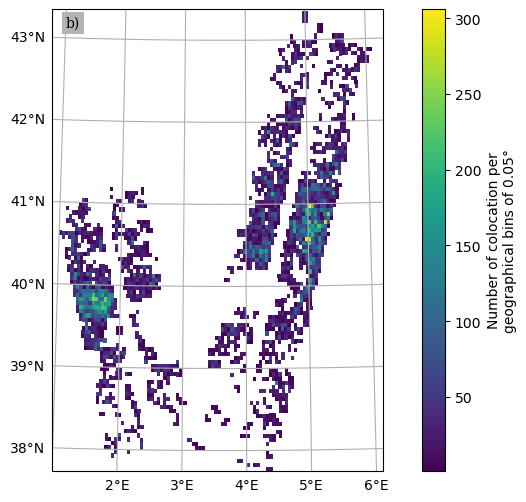

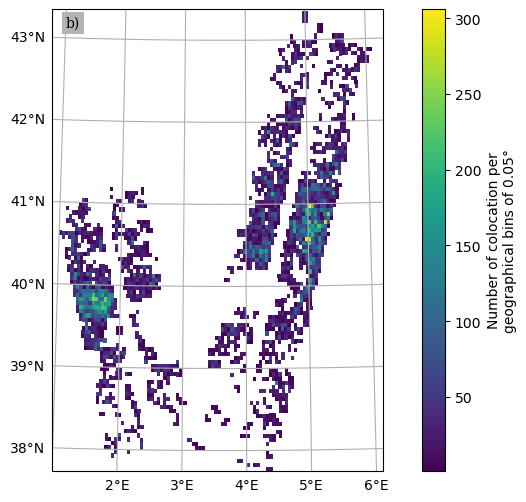

In [5]:
i=0
for df in [df250, df2]:

    dl = 0.5/10
    df["latbin"] = (df.latitude // dl) * dl
    df["lonbin"] = (df.longitude // dl) * dl
    dd = df.groupby(["latbin", "lonbin"]).longitude.count().to_xarray()
    dd.name = f'Number of colocation per geographical bins of {dl}°'
    dd['lonbin'] = dd['lonbin']+dl/2
    dd['latbin'] = dd['latbin']+dl/2
    
    
    fig = plt.figure(figsize=(10,6), frameon=False)
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    #ax.add_feature(cfeature.LAND,)
    dd.plot(ax=ax, transform=crs)
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels = False
    gl.right_labels = False

    #fig.savefig(os.path.join(images_dir, 'overview', f'geographical_distribution_{kl[i]}.png'))
    i+=1

    put_fig_letter(fig, ax, 'b')

_______
# Add other info on coloc


In [12]:
var_to_add = ['cycle_date', 'acceleration_north','w10_era5', 'iss_era5', 'inss', 'iews', 'v10','u10']


# 250m
dic = comb_list[0]
dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date']).set_index('row_number')
dfalti = pd.read_csv(ALTI[dic['alti_key']]).set_index('row_number').drop(columns=['longitude', 'latitude'])
dfwd = pd.read_csv(WD[dic['wd_key']]).set_index('row_number').drop(columns=['longitude', 'latitude'])
df = pd.concat([dfd, dfalti, dfwd], axis=1, verify_integrity=True)
df['iss_era5'] = np.sqrt(df.inss**2 + df.iews**2)
df['w10_era5'] = np.sqrt(df.u10**2 + df.v10**2)
df250 = pd.concat([df250, df[var_to_add]], axis=1)

# 250m
dic = comb_list[1]
dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date'] ).set_index('row_number')
dfalti = pd.read_csv(ALTI[dic['alti_key']]).set_index('row_number').drop(columns=['longitude', 'latitude', 'f'])
dfwd = pd.read_csv(WD[dic['wd_key']]).set_index('row_number').drop(columns=['longitude', 'latitude'])
df = pd.concat([dfd, dfalti, dfwd], axis=1, verify_integrity=True)
df['iss_era5'] = np.sqrt(df.inss**2 + df.iews**2)
df['w10_era5'] = np.sqrt(df.u10**2 + df.v10**2)
df2 = pd.concat([df2, df[var_to_add]], axis=1)



/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_49240/1177851857.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date']).set_index('row_number')
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_49240/1177851857.py:16: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfd = pd.read_csv(DRIFTER[dic['drifter_key']],parse_dates=['datetime', 'cycle_date'] ).set_index('row_number')


In [13]:
df250 = df250.loc[:,~df250.columns.duplicated()].copy()
df2 = df2.loc[:,~df2.columns.duplicated()].copy()
df250n = select_nearest_swot_coloc(df250)
df2n = select_nearest_swot_coloc(df2)

____
# Temporal distribution

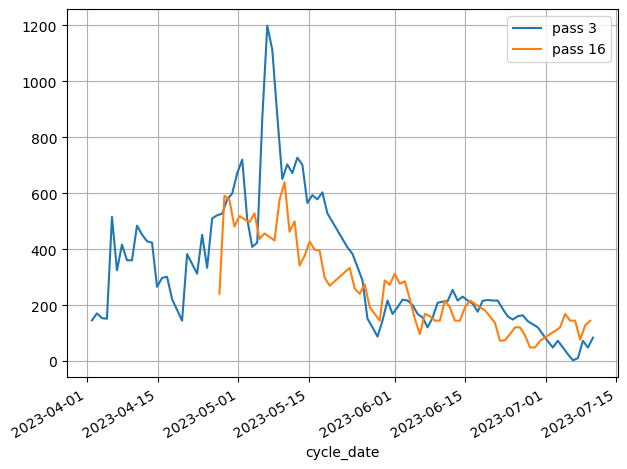

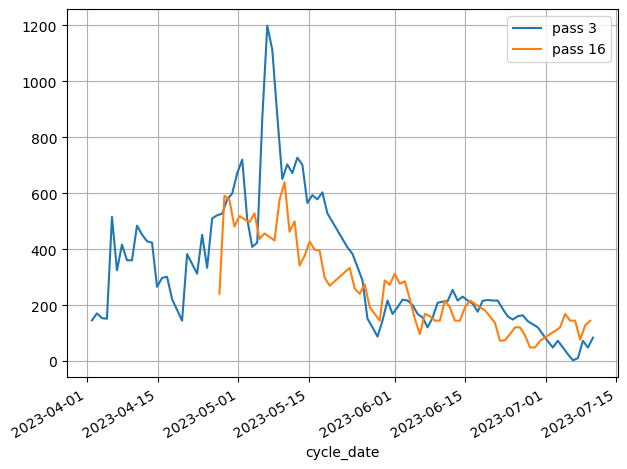

In [14]:
kl = ['250m', '2km']
i=0
for df in [df250, df2] :
    fig, axs = plt.subplots(1,1, sharex=True, frameon=False)
    df[df.pass_number==3].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 3')
    df[df.pass_number==16].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 16')
    axs.grid()
    axs.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'overview', f'temporal_distribution_{kl[i]}.png'))
    i+=1

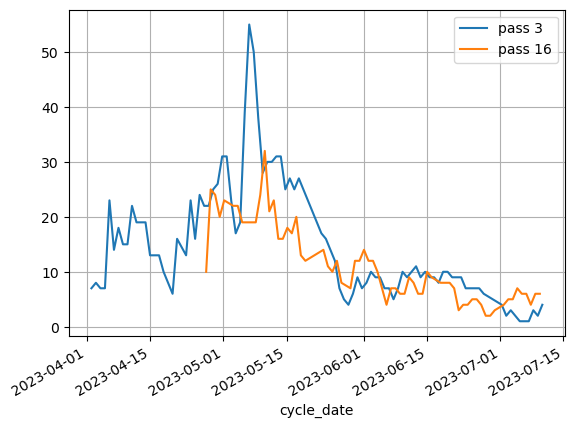

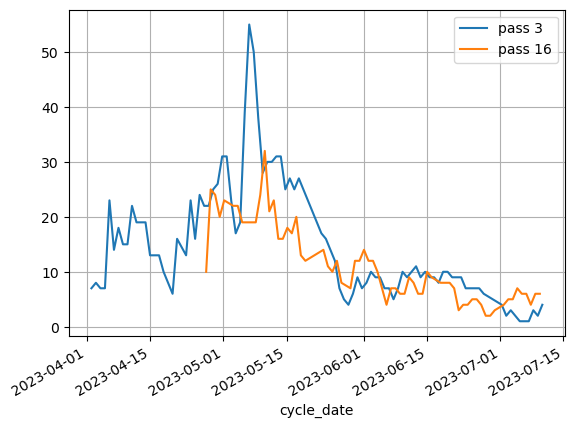

In [15]:
for dfc in [df250n, df2n] :
    fig, axs = plt.subplots(1,1, sharex=True)
    dfc[dfc.pass_number==3].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 3')
    dfc[dfc.pass_number==16].groupby(['cycle_date']).acceleration_north.count().plot(ax=axs, label = 'pass 16')
    axs.grid()
    axs.legend()
    #fig.tight_layout()

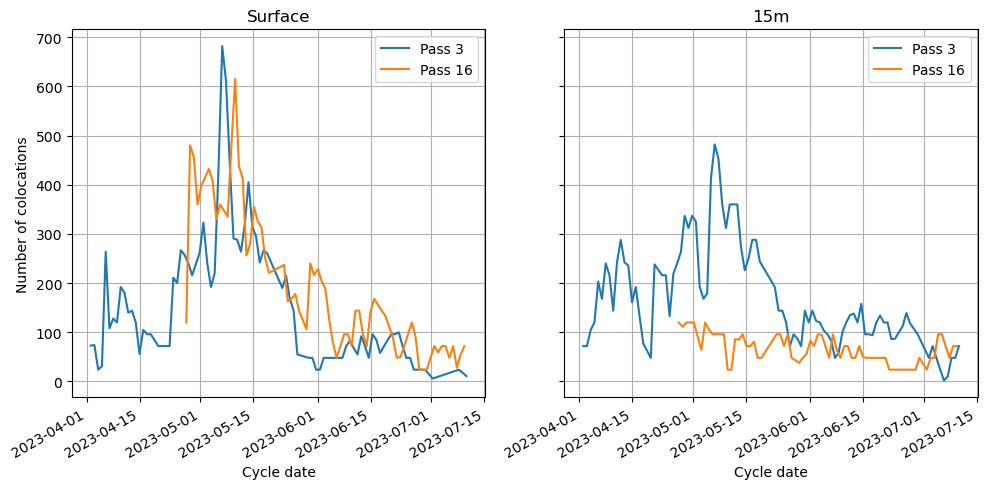

In [16]:

fig, axs = plt.subplots(1,2, sharey=True, frameon = False, figsize = (10, 5))
ax=axs[0]
df2[(df2.pass_number==3) & (df2.depth==0)].groupby(['cycle_date']).acceleration_north.count().plot(ax=ax, label = 'Pass 3')
df2[(df2.pass_number==16) & (df2.depth==0)].groupby(['cycle_date']).acceleration_north.count().plot(ax=ax, label = 'Pass 16')
ax.set_title('Surface')

ax=axs[1]
df2[(df2.pass_number==3) & (df2.depth==15)].groupby(['cycle_date']).acceleration_north.count().plot(ax=ax, label = 'Pass 3')
df2[(df2.pass_number==16) & (df2.depth==15)].groupby(['cycle_date']).acceleration_north.count().plot(ax=ax, label = 'Pass 16')
ax.set_title('15m')

for ax in axs :
    ax.grid()
    ax.legend()
    ax.set_xlabel('Cycle date')
    ax.set_ylabel('Number of colocations')
fig.tight_layout()
fig.savefig(os.path.join(images_dir, 'overview', f'temporal_distribution_pass_depth_DT{DT}.png'))

____
# Geographical distribution

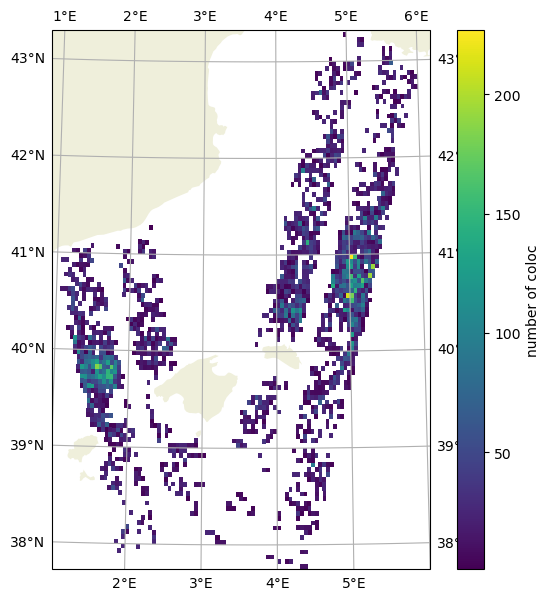

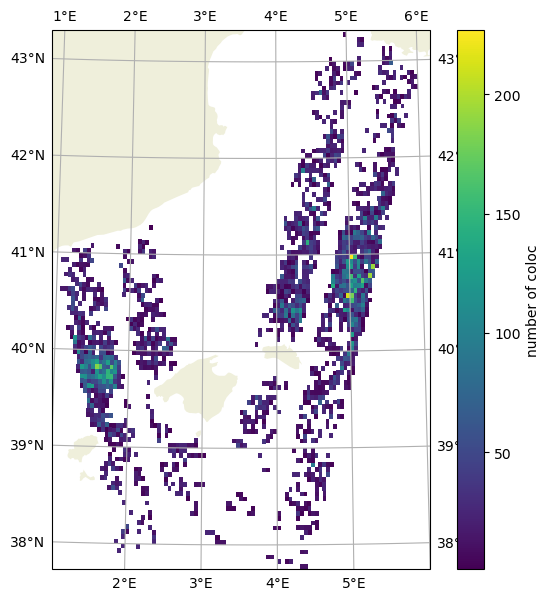

In [17]:
i=0
for df in [df250, df2]:

    dl = 0.5/10
    df["latbin"] = (df.latitude // dl) * dl
    df["lonbin"] = (df.longitude // dl) * dl
    dd = df.groupby(["latbin", "lonbin"]).acceleration_north.count().to_xarray()
    dd.name = 'number of coloc'
    dd['lonbin'] = dd['lonbin']+dl/2
    dd['latbin'] = dd['latbin']+dl/2
    
    
    fig = plt.figure(figsize=(7,7), frameon=False)
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(df.longitude.mean(), df.latitude.mean()))
    ax.add_feature(cfeature.LAND,)
    dd.plot(ax=ax, transform=crs)
    gl = ax.gridlines(draw_labels=True,)

    fig.savefig(os.path.join(images_dir, 'overview', f'geographical_distribution_{kl[i]}.png'))
    i+=1

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_49240/4105404947.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["latbin"] = (df.latitude // dl) * dl
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_49240/4105404947.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["lonbin"] = (df.longitude // dl) * dl
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_49240/4105404947.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

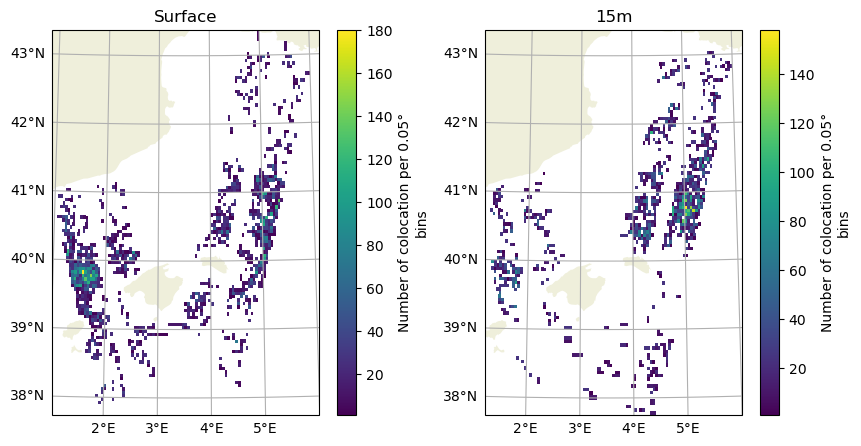

In [18]:
i=0
fig, axs = plt.subplots(1,2, sharey=True, frameon = False, figsize = (10, 5), subplot_kw={'projection':ccrs.Orthographic(3.5,40.5)})
for df in [df2[df2.depth==0], df2[df2.depth==15]]:
    dl = 0.05
    df["latbin"] = (df.latitude // dl) * dl
    df["lonbin"] = (df.longitude // dl) * dl
    dd = df.groupby(["latbin", "lonbin"]).acceleration_north.count().to_xarray()
    dd.name = 'Number of colocation per 0.05° bins'
    dd['lonbin'] = dd['lonbin']+dl/2
    dd['latbin'] = dd['latbin']+dl/2
    ax=axs[i]

    ax.add_feature(cfeature.LAND,)
    dd.plot(ax=ax, transform=crs)
    gl = ax.gridlines(draw_labels=True,)
    gl.top_labels=False   # suppress top labels
    gl.right_labels=False

    i+=1
axs[0].set_title('Surface')
axs[1].set_title('15m')
fig.savefig(os.path.join(images_dir, 'overview', f'geographical_distribution_passdepth_DT{DT}.png'))
i+=1

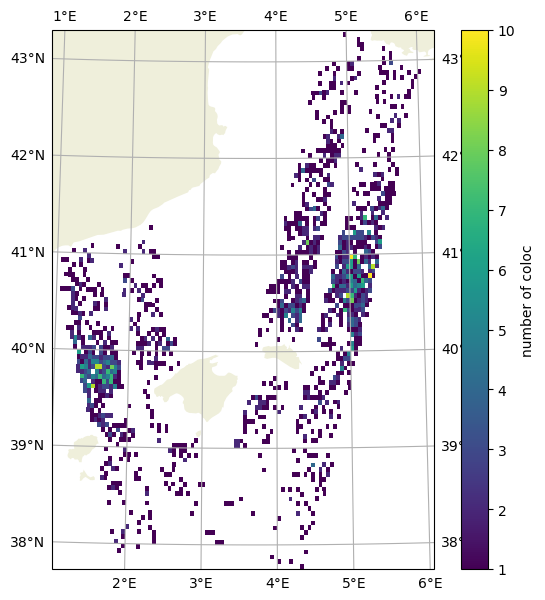

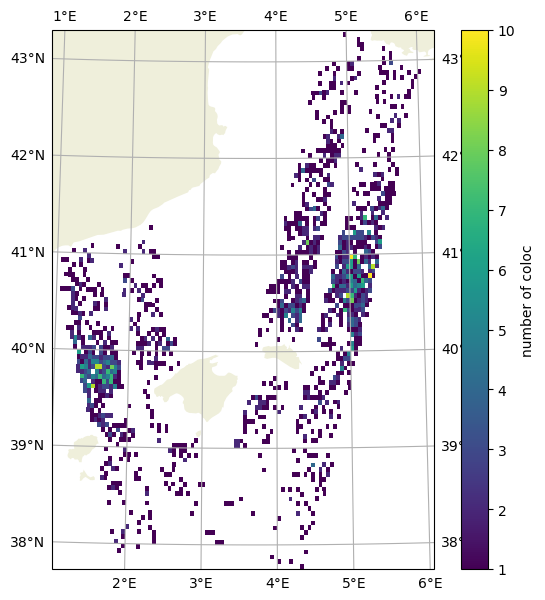

In [68]:
for dfc in [df250n, df2n]:
    dl = 0.5/10
    dfc["latbin"] = (dfc.latitude // dl) * dl
    dfc["lonbin"] = (dfc.longitude // dl) * dl
    dd = dfc.groupby(["latbin", "lonbin"]).acceleration_north.count().to_xarray()
    dd.name = 'number of coloc'
    dd['lonbin'] = dd['lonbin']+dl/2
    dd['latbin'] = dd['latbin']+dl/2
    
    
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    ax.add_feature(cfeature.LAND,)
    dd.plot(ax=ax, transform=crs)
    gl = ax.gridlines(draw_labels=True,)

____
# Geographical distribution

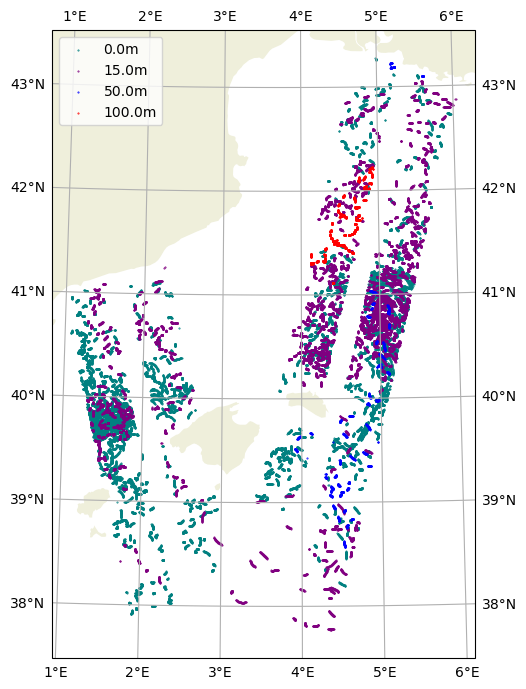

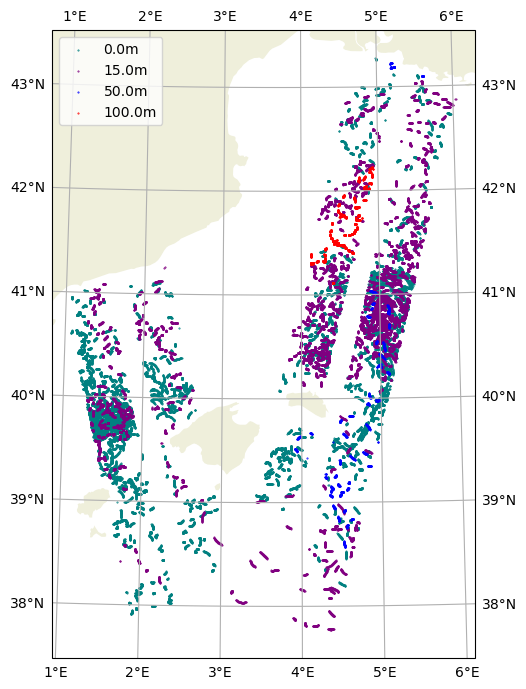

In [69]:
depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'} 
i=0
for df in [df250, df2]:
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'} # inverser couleur
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(7,7), frameon=False)
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    for d in sorted(df.depth.dropna().unique()) : 
        df[df.depth == d].plot.scatter('longitude', 'latitude', ax=ax, transform =crs, color = depthcolor[d], s = 0.2, label = f'{d}m')
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'overview' f'depth_geographical_distribution{kl[i]}.png'), dpi=200, bbox_inches='tight')
    i+=1

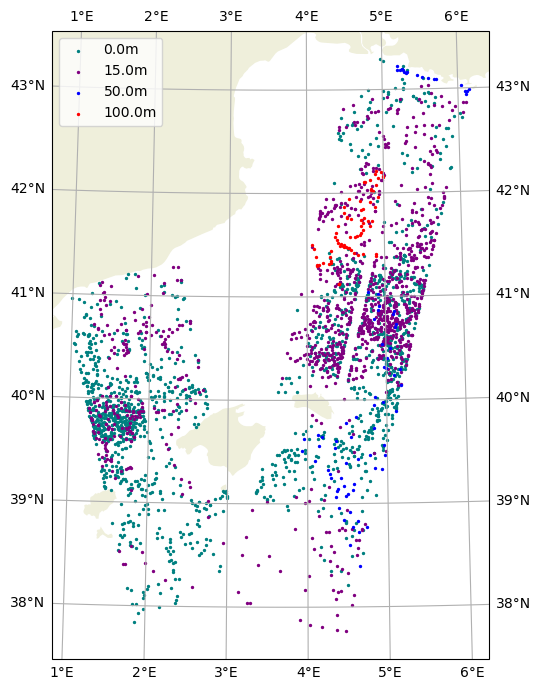

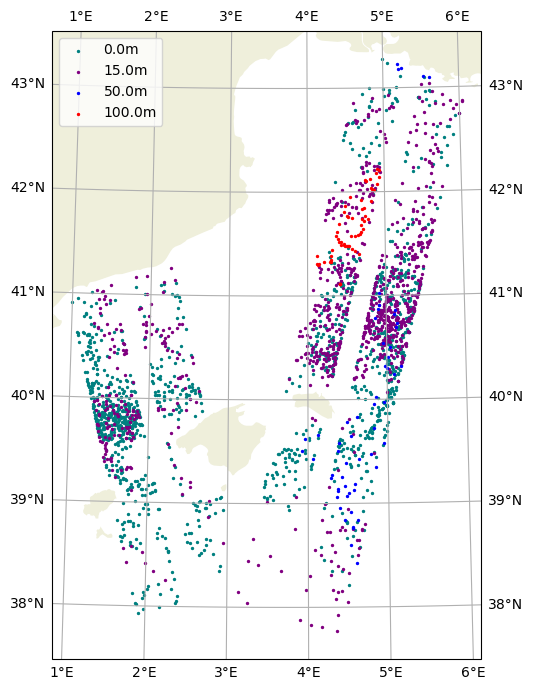

In [19]:
for dfc in [df250n, df2n]:
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'} # inverser couleur
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(7,7), frameon=False)
    ax = fig.add_subplot(111, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    for d in sorted(df.depth.dropna().unique()) : 
        dfc[dfc.depth == d].plot.scatter('longitude', 'latitude', ax=ax, transform =crs, color = depthcolor[d], s = 2, label = f'{d}m')
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    ax.legend()
    fig.tight_layout()
    #fig.savefig(os.path.join(images_dir, 'geographical_distribution.png'), dpi=200, bbox_inches='tight')


In [20]:
df.depth.unique()

array([ 15.,   0., 100.,  50.,  nan])

____
# WIND CONDITIONS

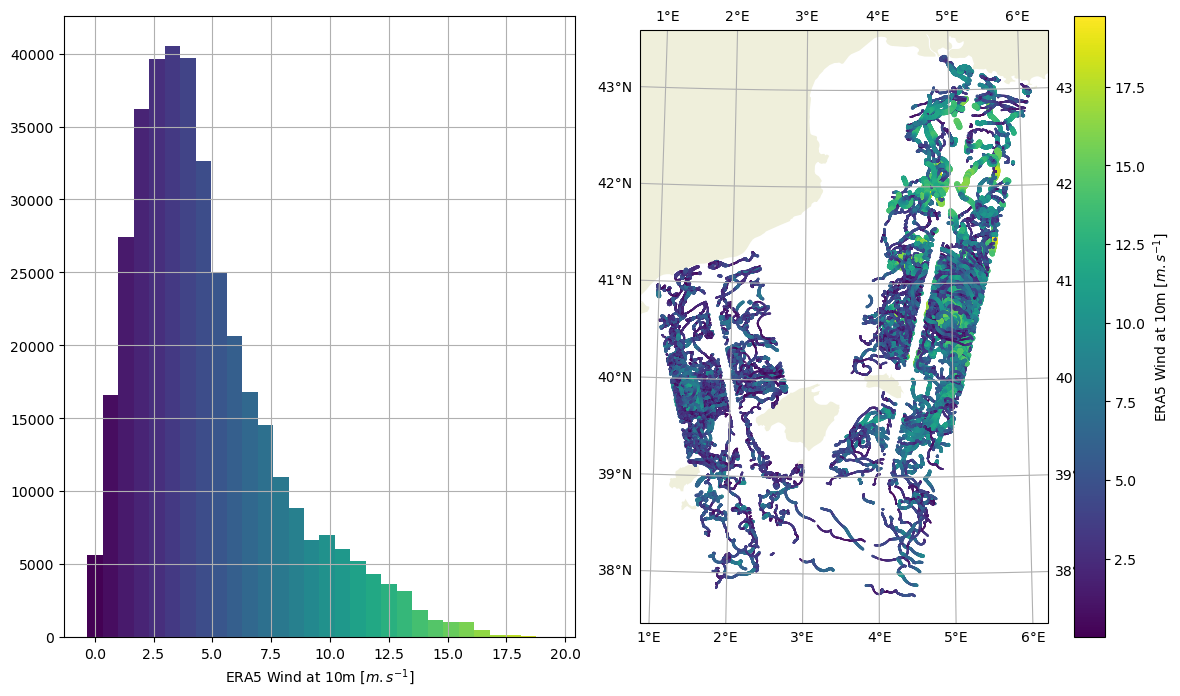

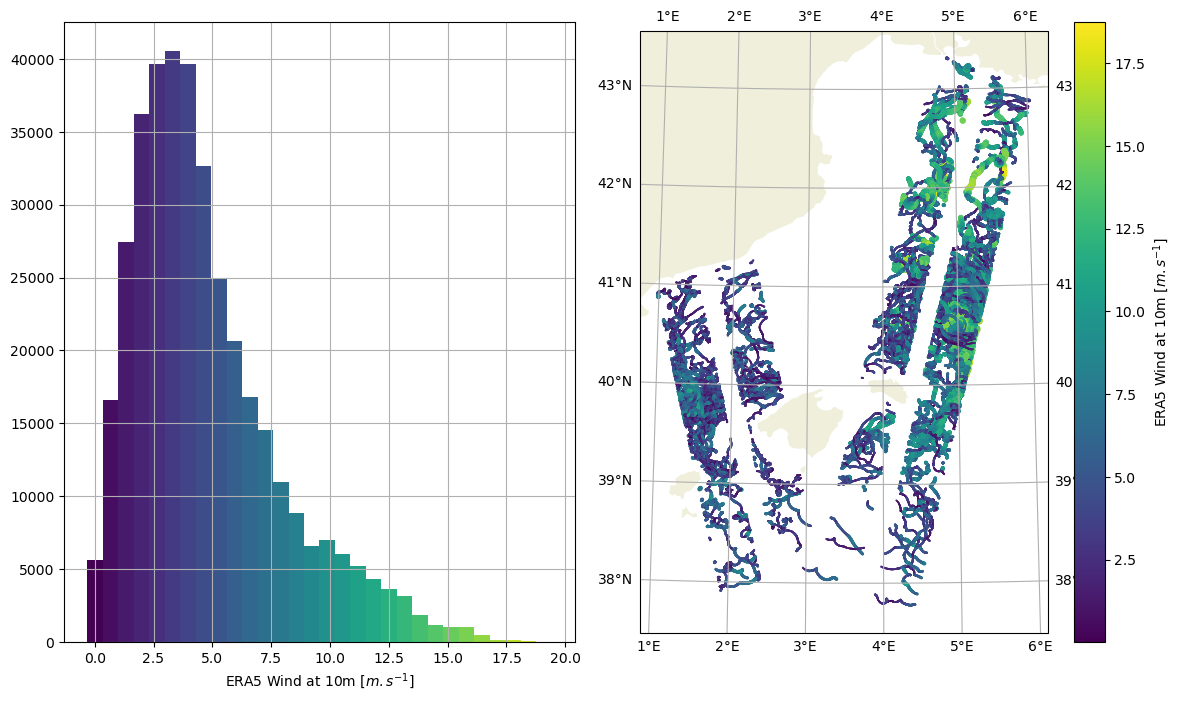

In [29]:
i=0
for df in [df250, df2]:
    
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'}
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(12,7), frameon=False)
    
    ax = fig.add_subplot(121)
    # This is the colormap I'd like to use.
    cm = plt.colormaps.get_cmap('viridis')
    # Get the histogram
    Y,X = np.histogram(df.w10_era5, bins = 30)
    x_span = X.max()-X.min()
    C = [cm(((x-X.min())/x_span)) for x in X]
    ax.bar(X[:-1],Y,color=C,width=X[1]-X[0])
    ax.grid()
    ax.set_xlabel(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    #a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
    a = ax.scatter(df.longitude, df.latitude, c=df.w10_era5, transform =crs, s=df.iss_era5*20)
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    
    cb = plt.colorbar(a)
    cb.set_label(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    #cbar = fig.colorbar(a, ax=ax)
    #cbar.set_label('a')
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'overview', 'wind_condition_{kl[i]}.png'), dpi=200, bbox_inches='tight')
    i+=1

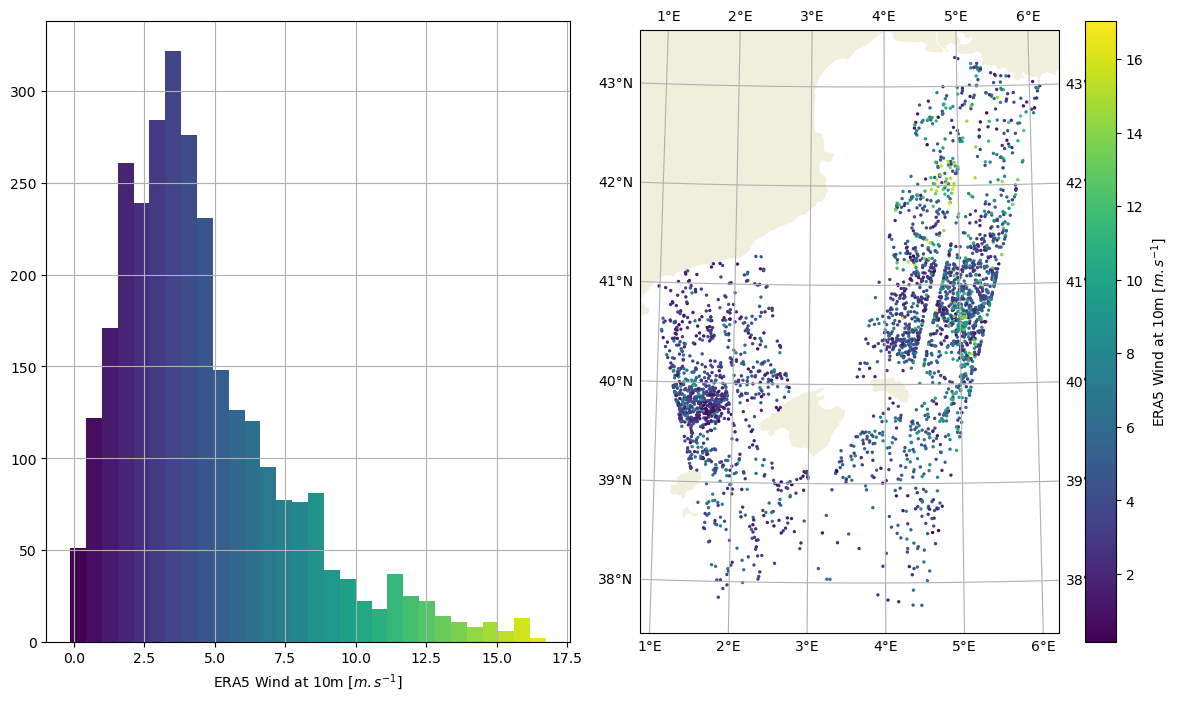

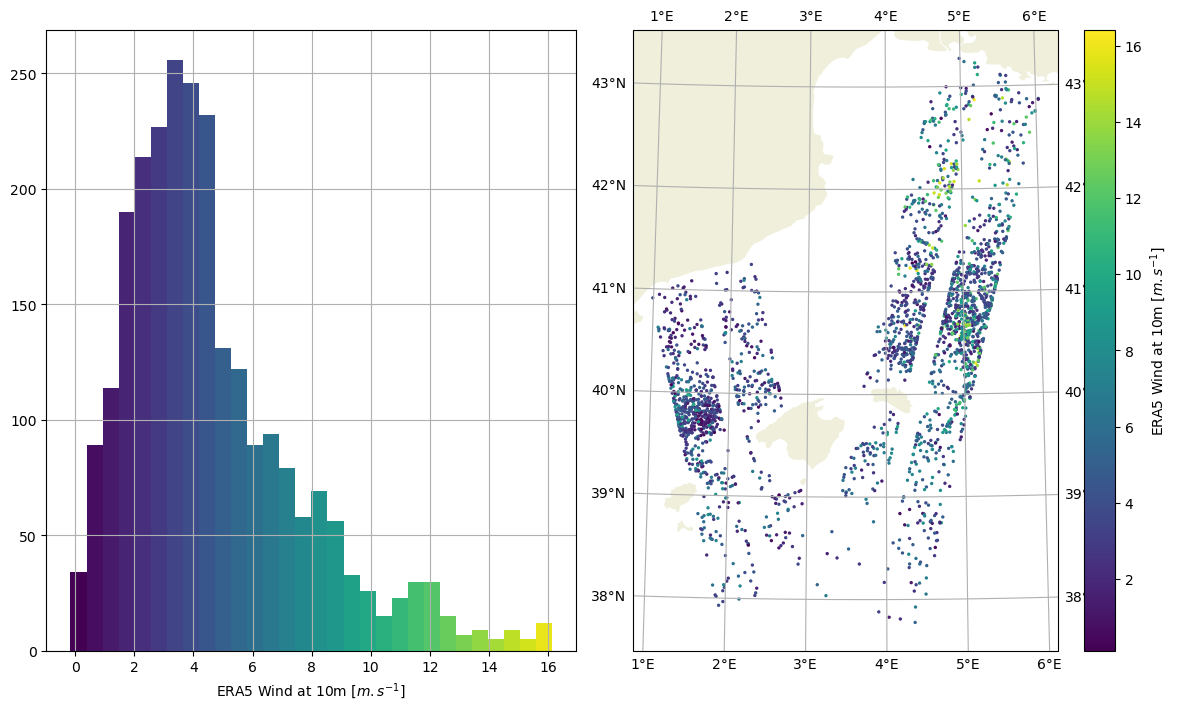

In [30]:
for dfc in [df250n, df2n]:
    depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'}
    #bbox = [2.7, 6.1, 36.6, 43.4]
    fig = plt.figure(figsize=(12,7), frameon=False)
    
    ax = fig.add_subplot(121)
    # This is the colormap I'd like to use.
    cm = plt.colormaps.get_cmap('viridis')
    # Get the histogram
    Y,X = np.histogram(dfc.w10_era5, bins = 30)
    x_span = X.max()-X.min()
    C = [cm(((x-X.min())/x_span)) for x in X]
    ax.bar(X[:-1],Y,color=C,width=X[1]-X[0])
    ax.grid()
    ax.set_xlabel(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    #a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
    a = ax.scatter(dfc.longitude, dfc.latitude, c=dfc.w10_era5, transform =crs, s=2)
    #ax.set_extent(bbox)
    ax.add_feature(cfeature.LAND,)
    
    gl = ax.gridlines(draw_labels=True,)
    gl.xlabels_top = False
    gl.ylabels_right = False
    
    cb = plt.colorbar(a)
    cb.set_label(r'ERA5 Wind at 10m [$m.s^{-1}$]')
    
    #cbar = fig.colorbar(a, ax=ax)
    #cbar.set_label('a')
    fig.tight_layout()
    #fig.savefig(os.path.join(images_dir, 'geographical_distribution_wd.png'), dpi=200, bbox_inches='tight')


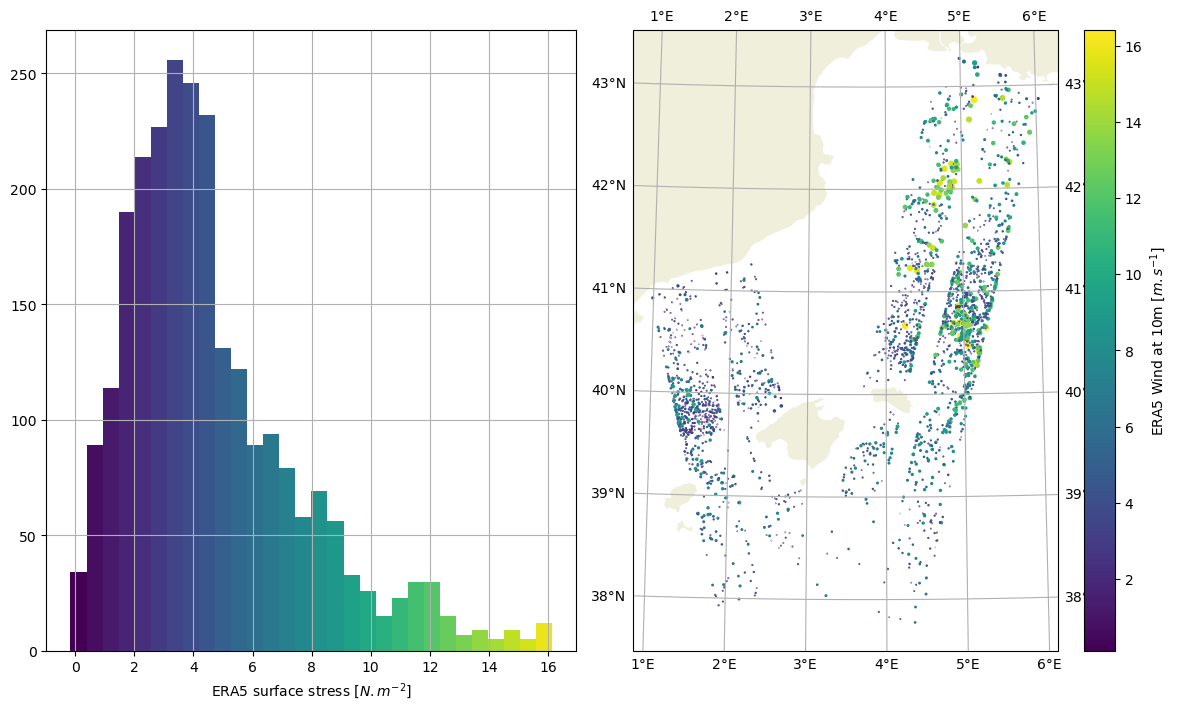

In [31]:
depthcolor = {0:'teal', 15:'purple', 50:'b', 100:'red'}
#bbox = [2.7, 6.1, 36.6, 43.4]
fig = plt.figure(figsize=(12,7), frameon=False)

ax = fig.add_subplot(121)
# This is the colormap I'd like to use.
cm = plt.colormaps.get_cmap('viridis')
# Get the histogram
Y,X = np.histogram(dfc.w10_era5, bins = 30)
x_span = X.max()-X.min()
C = [cm(((x-X.min())/x_span)) for x in X]
ax.bar(X[:-1],Y,color=C,width=X[1]-X[0])
ax.grid()
ax.set_xlabel(r'ERA5 surface stress [$N.m^{-2}$]')

ax = fig.add_subplot(122, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
#a = dfc.plot.scatter('longitude', 'latitude',c='w10_era5', ax=ax, transform =crs, s=2)
a = ax.scatter(dfc.longitude, dfc.latitude, c=dfc.w10_era5, s=dfc.iss_era5*20, transform =crs)
#ax.set_extent(bbox)
ax.add_feature(cfeature.LAND,)

gl = ax.gridlines(draw_labels=True,)
gl.xlabels_top = False
gl.ylabels_right = False

cb = plt.colorbar(a)
cb.set_label(r'ERA5 Wind at 10m [$m.s^{-1}$]')

#cbar = fig.colorbar(a, ax=ax)
#cbar.set_label('a')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'geographical_distribution_wd.png'), dpi=200, bbox_inches='tight')


In [ ]:
for df in [df250, df2] : 
    fig, axs = plt.subplots(1,1, sharex=True)
    df[df.pass_number==3].groupby('cycle_date').w10_era5.mean().plot(ax=axs, label = 'pass 3')
    df[df.pass_number==16].groupby('cycle_date').w10_era5.mean().plot(ax=axs, label = 'pass 16')
    axs.grid()
    axs.legend()
    axs.set_ylabel(r'ERA5 Wind at 10m [$m.s^{-1}$]')